# Coffee Quality Prediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
mpl.style.use('seaborn-v0_8-colorblind')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score



## Import Data

In [2]:
coffee = pd.read_csv('coffee.csv')
coffee.head(10)

,Date,Method,Origin,Size,Grind,Time,Output,Note,Score
0,20211201.0,Espresso,Guatamala,8,21.3,30,(30.9),Pluck’s fine; taste okay,3
1,20211205.0,Espresso,Guatamala,8,21.6,30,45.9,NaN,3
2,20211208.0,Espresso,Guatamala,8,21.6,30,51.4,NaN,3
3,20211221.0,Espresso,Guatamala,8,21.7,30,73,NaN,3
4,20220106.0,Espresso,Guatamala,8,22.4,25,64,NaN,3
5,NaN,Espresso,Guatamala,8,20.4,27,100,Extraction too fast,2
6,20220330.0,Espresso,Guatamala,8,20.5,23,54.6,NaN,3
7,20220402.0,Espresso,Guatamala,8,21,50,60,NaN,3
8,20220403.0,Espresso,Guatamala,7,22.1,23,56.7,NaN,3
9,20220405.0,Espresso,Guatamala,6,22.4,25,48.4,NaN,3


In [3]:
coffee.dtypes

Date      float64
Method     object
Origin     object
Size        int64
Grind      object
Time        int64
Output     object
Note       object
Score       int64
dtype: object

## Data Cleaning

In [4]:
coffee['Date'] = coffee['Date'].ffill()
coffee['Date'] = coffee['Date'].astype(str).str[:8]
coffee['Date'] = pd.to_datetime(coffee['Date'])

coffee['Output'] = coffee['Output'].str.replace("(", "").str.replace(")", "").str.replace("？", "").astype(float)

coffee['Grind'] = coffee['Grind'].str.replace(" ", "").astype(float)

coffee.loc[coffee['Note'].isna(), 'Note'] = 'None'

In [5]:
origins = ['Ethiopia', 'Colombia', 'Brazil', 'Guatemala', 'Costa Rica', 'Kenya', 'Honduras', 'Mexico', 'Peru', 'Panama', 'Indoesnia', 'Other']
coffee['Origin'].unique()

array(['Guatamala', 'Indoesnia Sumatra', 'Houseblend', 'Kenya',
       'Ethiopian Yirgacheffe', 'Fineprint Espresso Blend',
       'Fineprint Espresso Blend Gold', 'Ethiopian', 'Bali', 'Ralph’s',
       'Bluestone Lane Maverick', 'Bluestone Lane Baystone', 'Stumptown',
       'Kaldi Premium', 'Angelo Blue', 'Yahara El Salvador',
       'Fineprint Baroida Estate', 'Livdiff', 'Blacklist Accent'],
      dtype=object)

In [6]:
coffee.loc[coffee['Origin']=='Bali', 'Origin'] = 'Indonesia'
coffee.loc[coffee['Origin']=='Guatamala', 'Origin'] = 'Guatemala'

def origin_group(origin):
    for o in origins:
        if o in origin:
            return o
    return 'Other'

coffee['Origin'] = coffee['Origin'].apply(origin_group)
coffee['Origin'].unique()

array(['Guatemala', 'Indoesnia', 'Other', 'Kenya', 'Ethiopia'],
      dtype=object)

In [7]:
coffee.dtypes

Date      datetime64[ns]
Method            object
Origin            object
Size               int64
Grind            float64
Time               int64
Output           float64
Note              object
Score              int64
dtype: object

In [8]:
coffee.isna().sum().sum()

np.int64(0)

## Export Clean Dataset

In [9]:
with open('coffee_cleaned.csv', 'w') as f:
    coffee.to_csv(f, index=False)

## Exploratory Data Analysis

In [10]:
coffee.groupby('Method').aggregate({'Score': ['mean', 'std']})

Score          
              mean       std
Method                      
Espresso  3.522059  1.067825
Filter    3.212121  0.857233

In [11]:
fig = px.box(
    data_frame=coffee,
    y='Score',
    x='Origin',
    title='Coffee Score by Origin',
    color='Origin',
    width=800,
    height=600
)
fig.show()

In [12]:
fig = px.scatter_3d(
    data_frame=coffee,
    x='Time',
    y='Grind',
    z='Score',
    size='Size',
    color='Origin',
    title='Coffee Score by Time, Grind, and Size',
    width=800,
    height=600
)

fig.show()

## Data Preprocessing

In [13]:
coffee.drop(columns=['Date', 'Note'], inplace=True)
coffee = pd.get_dummies(coffee, columns=['Method', 'Origin'])

coffee.head(2)

,Size,Grind,Time,Output,Score,Method_Espresso,Method_Filter,Origin_Ethiopia,Origin_Guatemala,Origin_Indoesnia,Origin_Kenya,Origin_Other
0,8,21.3,30,30.9,3,True,False,False,True,False,False,False
1,8,21.6,30,45.9,3,True,False,False,True,False,False,False


In [14]:
X = coffee.drop(columns=['Score']).reset_index(drop=True)
y = coffee['Score']

In [15]:
def stratified_split(X, y, test_size=.2, random_state=42):
    idx = []
    origins = X.iloc[0, 6:].index

    for o in origins:
        idx += X.loc[X[o] == True].sample(frac=test_size, random_state=random_state).index.to_list()
    return idx

test_idx = stratified_split(X, y, test_size=.2, random_state=42)

X_train = X.drop(index=test_idx).reset_index(drop=True)
y_train = y.drop(index=test_idx).reset_index(drop=True)
X_test = X.loc[test_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)

## Model Training

In [16]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

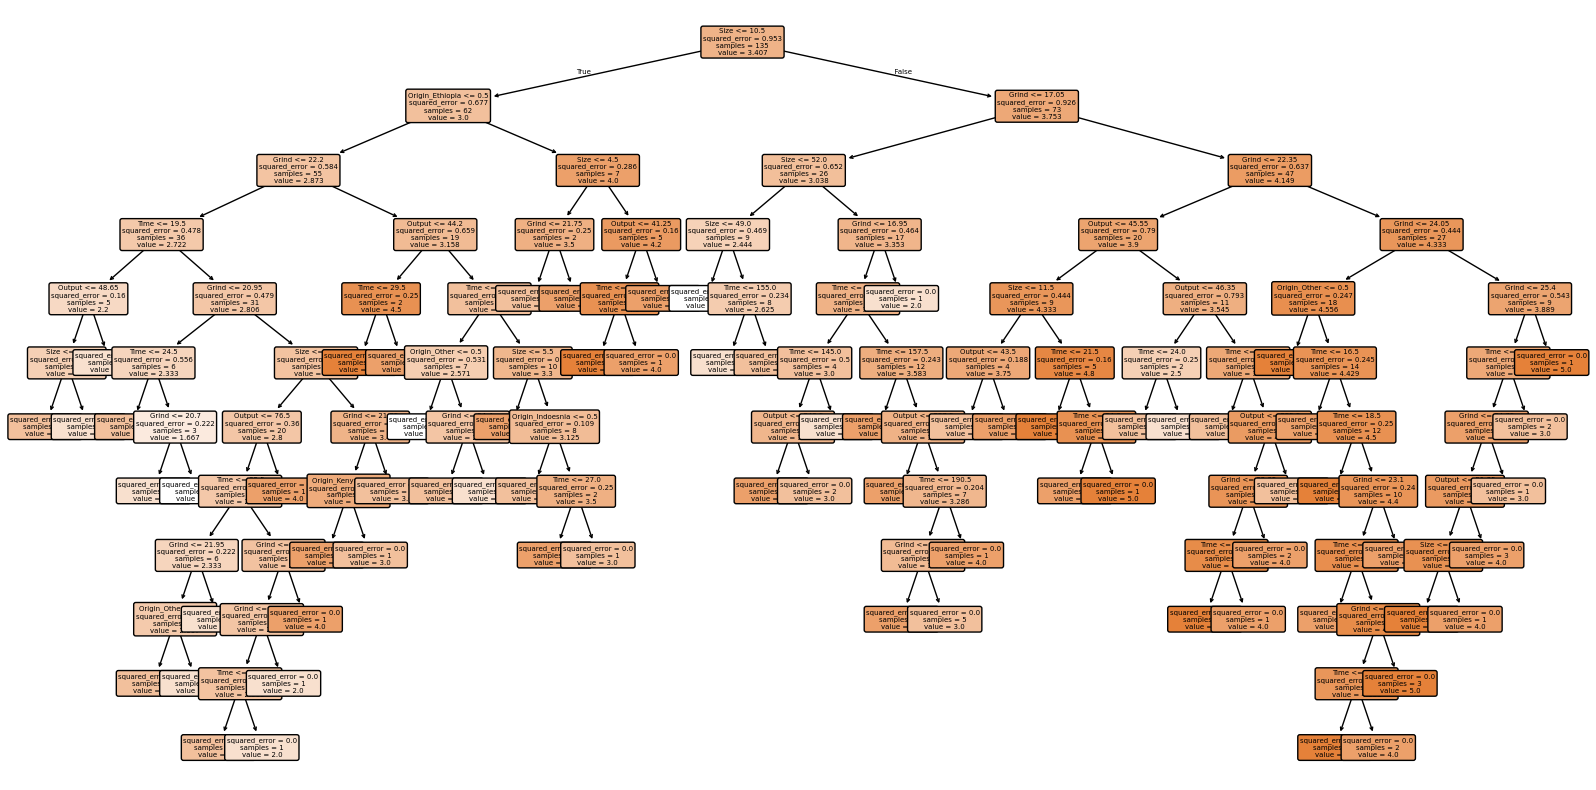

In [17]:
fig = plt.figure(figsize=(20, 10))
fig = plot_tree(tree, feature_names=X_train.columns, filled=True, rounded=True, fontsize=5)

In [18]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'criterion': ['squared_error', 'friedman_mse'],
    'learning_rate': [.001, .01, .05],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
gb_grid = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42), param_grid=gb_params, cv=5, n_jobs=-1, verbose=2)
gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END criterion=squared_error, learning_rate=0.001, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END criterion=squared_error, learning_rate=0.001, max_d

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse'], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [5, 10], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [19]:
gb_best = GradientBoostingRegressor(**gb_grid.best_params_)
gb_best.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thele

## Evaluation

In [20]:
y_pred = tree.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MSE: {mse:.3f}")

R2: -0.294
MSE: 1.882


In [21]:
y_pred = gb_best.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"MSE: {mse:.3f}")

R2: 0.186
MSE: 1.184


## Inference

In [46]:
sample_01 = pd.DataFrame(data=[[7, 22, 30, 42, True, False, True, False, False, False, False]], columns=X.columns)
sample_01

,Size,Grind,Time,Output,Method_Espresso,Method_Filter,Origin_Ethiopia,Origin_Guatemala,Origin_Indoesnia,Origin_Kenya,Origin_Other
0,7,22,30,42,True,False,True,False,False,False,False


In [47]:
gb_best.predict(sample_01)[0]

np.float64(3.6953994333134985)